# 16 — UMA-16 v2 Audio Capture & Offline Beamforming

**Goal**: validate the full audio capture → CSM → 2D beamforming pipeline
on real data from the miniDSP UMA-16 v2 16-mic array.

Steps:
1. Device discovery and channel verification (all 16 channels are raw mic audio)
2. Record a 5-second clip with a known-direction source
3. Compute the Cross-Spectral Matrix (CSM) from all 16 channels
4. 1D azimuth beamforming — compare peaks to nb15 HPBW predictions
5. 2D (azimuth × elevation) beamforming — full heatmap
6. Frequency sweep — DoA consistency vs spatial Nyquist


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sounddevice as sd
import scipy.io.wavfile as wavfile
import scipy.signal as signal
from scipy.linalg import inv
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C       = 343.0
FS      = 48000
N_MICS  = 16
NYQUIST = C / (2 * 0.042)   # ~4083 Hz

# UMA-16 v2 mic positions (camera/observer side — x negated vs manual Figure 1)
d = 0.042
_xy = np.array([
    (-1, -3), (-3, -3), (-1, -1), (-3, -1),
    (-1, +1), (-3, +1), (-1, +3), (-3, +3),
    (+3, +3), (+1, +3), (+3, +1), (+1, +1),
    (+3, -1), (+1, -1), (+3, -3), (+1, -3),
], dtype=float) * (d / 2)
MIC_X = -_xy[:, 0]
MIC_Y =  _xy[:, 1]

WAV_OUT = Path('../test/UMA16/capture_nb16.wav')


## 1  Device Discovery

Locate the UMA-16 v2 in the sounddevice device list and confirm it exposes
16 input channels at 48 kHz.  All 16 channels are raw mic audio (no processed
channels, unlike the ReSpeaker in Phase 2).

In [2]:
devs = sd.query_devices()
print('All input devices:')
for i, d in enumerate(devs):
    if d['max_input_channels'] > 0:
        print(f'  [{i:2d}] {d["name"]:50s}  '
              f'{d["max_input_channels"]}ch  '
              f'{d["default_samplerate"]:.0f}Hz')

uma_idx = None
for i, d in enumerate(devs):
    if 'uma' in d['name'].lower() or 'uma16' in d['name'].lower():
        uma_idx = i; uma_dev = d; break
if uma_idx is None:
    # fallback: device 12 is the known index from hardware testing
    uma_idx = 12; uma_dev = devs[12]

print(f'\nUMA-16 v2 at device index {uma_idx}:')
print(f'  Name:     {uma_dev["name"]}')
print(f'  Channels: {uma_dev["max_input_channels"]}')
print(f'  Rate:     {uma_dev["default_samplerate"]:.0f} Hz')
print(f'  Latency:  {uma_dev["default_low_input_latency"]*1000:.1f} ms (low)')


All input devices:
  [ 0] HDA Intel PCH: ALC1220 Analog (hw:0,0)              2ch  44100Hz
  [ 2] HDA Intel PCH: ALC1220 Alt Analog (hw:0,2)          2ch  44100Hz
  [11] Logitech BRIO: USB Audio (hw:3,0)                   2ch  48000Hz
  [12] UMA16v2: USB Audio (hw:4,0)                         16ch  44100Hz
  [13] sysdefault                                          128ch  48000Hz
  [23] pipewire                                            64ch  44100Hz
  [25] default                                             64ch  44100Hz

UMA-16 v2 at device index 12:
  Name:     UMA16v2: USB Audio (hw:4,0)
  Channels: 16
  Rate:     44100 Hz
  Latency:  8.7 ms (low)


## 2  Channel Verification

Record 2 seconds of ambient audio and measure RMS level on each of the 16 channels.
All channels should be similar (within ~2–3×) confirming all mics are live and
the array is functioning correctly.

In [3]:
print('Recording 2s ambient (keep quiet) ...')
amb = sd.rec(2 * FS, samplerate=FS, channels=N_MICS, dtype='float32', device=uma_idx)
sd.wait()
print('Done.')

rms_vals = np.sqrt(np.mean(amb**2, axis=0))
print('\nAmbient RMS per channel:')
for i, r in enumerate(rms_vals):
    bar = '#' * int(r / rms_vals.max() * 30)
    print(f'  ch{i:2d}: {r:.2e}  {bar}')
print(f'\nMax/min ratio: {rms_vals.max()/rms_vals.min():.2f}x')


Recording 2s ambient (keep quiet) ...
Done.

Ambient RMS per channel:
  ch 0: 8.35e-05  #########################
  ch 1: 8.18e-05  #########################
  ch 2: 8.97e-05  ###########################
  ch 3: 8.53e-05  ##########################
  ch 4: 9.32e-05  ############################
  ch 5: 9.62e-05  #############################
  ch 6: 9.03e-05  ###########################
  ch 7: 8.30e-05  #########################
  ch 8: 8.42e-05  #########################
  ch 9: 9.05e-05  ###########################
  ch10: 9.27e-05  ############################
  ch11: 9.06e-05  ###########################
  ch12: 8.22e-05  #########################
  ch13: 7.99e-05  ########################
  ch14: 9.79e-05  ##############################
  ch15: 8.09e-05  ########################

Max/min ratio: 1.22x


## 3  Live Recording

Record 5 seconds.  Place a sound source (tone, clap, speaker) at a known azimuth
angle if possible — ideally 0° (boresight) or a clearly off-axis direction.
The recording is saved to `test/UMA16/capture_nb16.wav` for offline replay.

Recording 5s — make a sound now ...
Done.
Saved ../test/UMA16/capture_nb16.wav  (240000 samples, 16 channels)


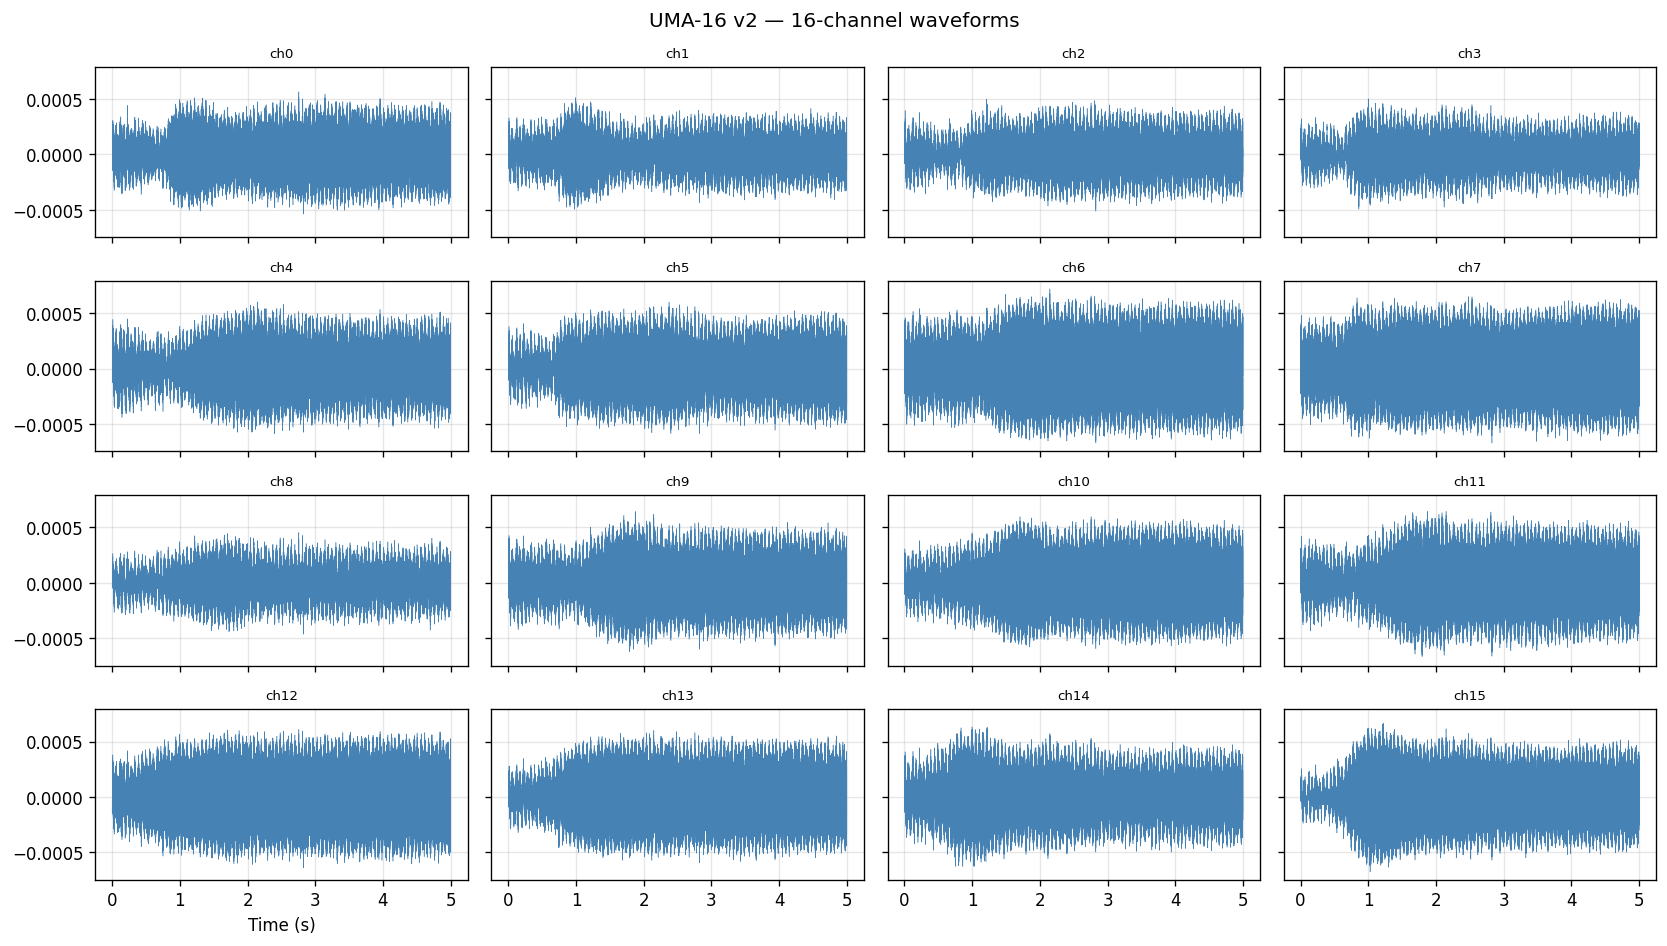

In [4]:
RECORD_SECS = 5
print(f'Recording {RECORD_SECS}s — make a sound now ...')
rec = sd.rec(RECORD_SECS * FS, samplerate=FS, channels=N_MICS,
             dtype='float32', device=uma_idx)
sd.wait()
print('Done.')

WAV_OUT.parent.mkdir(parents=True, exist_ok=True)
wavfile.write(WAV_OUT, FS, (rec * 32767).astype(np.int16))
print(f'Saved {WAV_OUT}  ({rec.shape[0]} samples, {N_MICS} channels)')

t = np.arange(rec.shape[0]) / FS
fig, axes = plt.subplots(4, 4, figsize=(14, 8), sharex=True, sharey=True)
for i, ax in enumerate(axes.ravel()):
    ax.plot(t, rec[:, i], linewidth=0.3, color='steelblue')
    ax.set_title(f'ch{i}', fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1][0].set_xlabel('Time (s)')
plt.suptitle('UMA-16 v2 — 16-channel waveforms')
plt.tight_layout()
plt.savefig('uma16_capture_waveforms.png', dpi=150)
plt.show()


## 4  Cross-Spectral Matrix

Compute the CSM from the 16-channel recording using Welch-style block averaging.
Beamforming frequency: 3000 Hz — well below the ~4083 Hz spatial Nyquist and
within the useful directionality window (>2.7 kHz for this 126 mm aperture).

CSM at 3000.0 Hz,  233 blocks
CSM diagonal (power per channel):
  ch 0: 1.832e-07
  ch 1: 1.897e-07
  ch 2: 1.720e-07
  ch 3: 1.573e-07
  ch 4: 2.017e-07
  ch 5: 1.620e-07
  ch 6: 2.388e-07
  ch 7: 1.756e-07
  ch 8: 1.814e-07
  ch 9: 2.120e-07
  ch10: 1.527e-07
  ch11: 1.981e-07
  ch12: 1.805e-07
  ch13: 1.651e-07
  ch14: 1.726e-07
  ch15: 1.746e-07


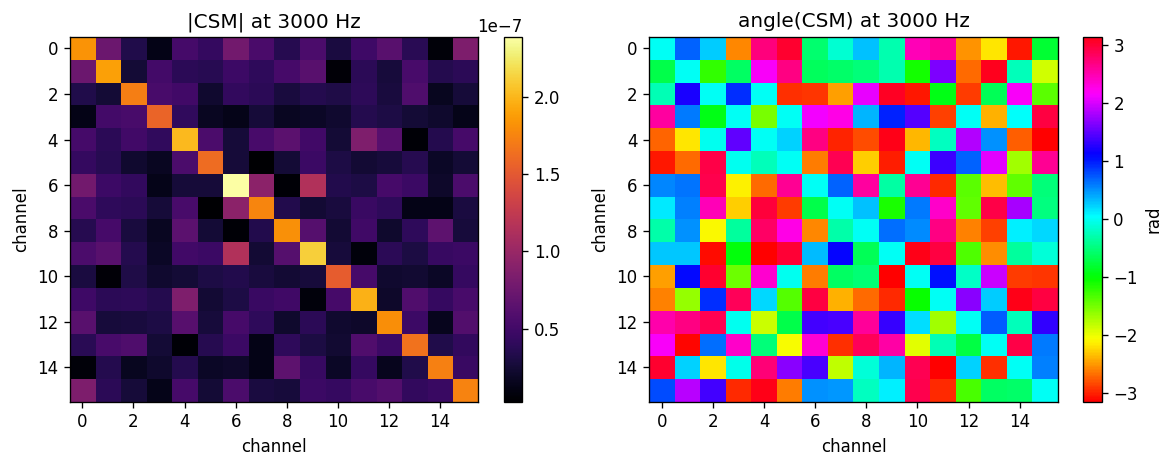

In [5]:
def compute_csm(audio, freq, block_size=2048, hop=1024):
    n_samp, n_ch = audio.shape
    freqs  = np.fft.rfftfreq(block_size, 1 / FS)
    f_idx  = np.argmin(np.abs(freqs - freq))
    f_act  = freqs[f_idx]
    win    = np.hanning(block_size)
    R = np.zeros((n_ch, n_ch), dtype=complex)
    count = 0
    for start in range(0, n_samp - block_size, hop):
        block = audio[start:start + block_size] * win[:, None]
        F = np.fft.rfft(block, axis=0)[f_idx]
        R += np.outer(F, F.conj())
        count += 1
    return R / count, f_act, count


FREQ_BF = 3000.0
R_csm, f_act, n_blocks = compute_csm(rec, FREQ_BF)
print(f'CSM at {f_act:.1f} Hz,  {n_blocks} blocks')
print(f'CSM diagonal (power per channel):')
for i in range(N_MICS):
    print(f'  ch{i:2d}: {R_csm[i,i].real:.3e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(np.abs(R_csm), cmap='inferno', aspect='auto')
axes[0].set_title(f'|CSM| at {f_act:.0f} Hz')
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(np.angle(R_csm), cmap='hsv', aspect='auto',
                     vmin=-np.pi, vmax=np.pi)
axes[1].set_title(f'angle(CSM) at {f_act:.0f} Hz')
plt.colorbar(im1, ax=axes[1], label='rad')
for ax in axes:
    ax.set_xlabel('channel'); ax.set_ylabel('channel')
plt.tight_layout()
plt.savefig('uma16_csm.png', dpi=150)
plt.show()


## 5  1D Azimuth Beamforming

Beamform along the azimuth axis (elevation fixed at 0°) with D&S, MVDR, and
CLEAN-SC.  Expected HPBW from nb15 at 3000 Hz: ~43°.

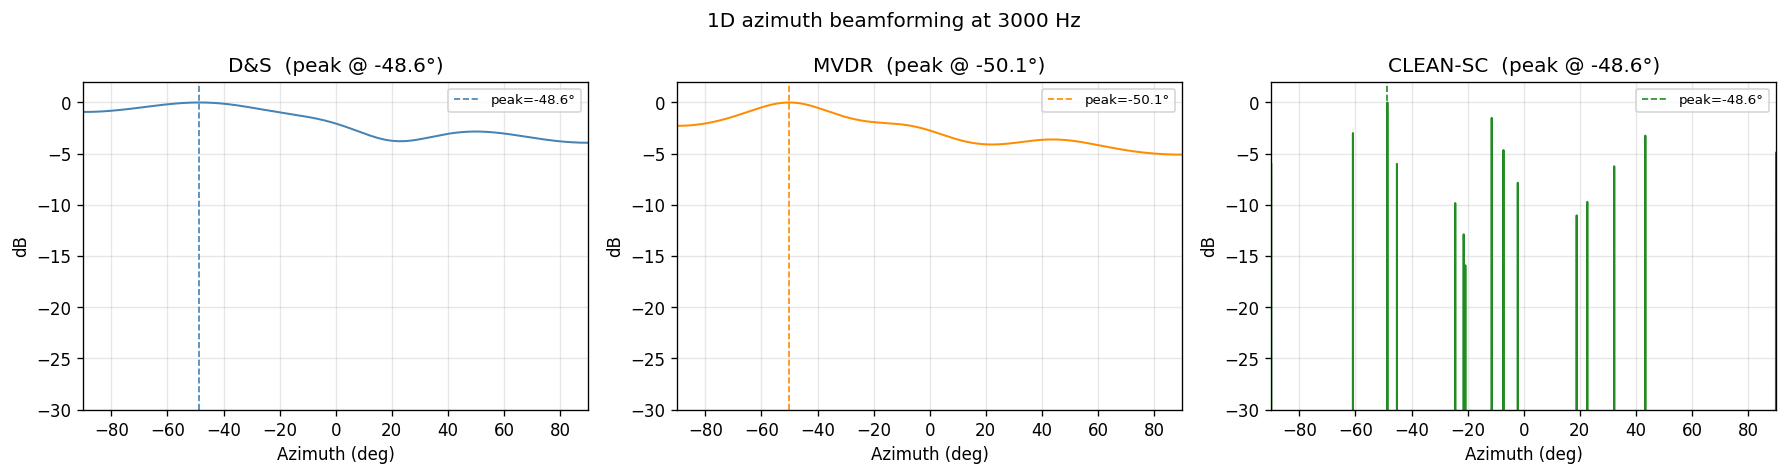

Peak DoA at 3000 Hz:
  D&S:      -48.6°
  MVDR:     -50.1°
  CLEAN-SC: -48.6°
  nb15 predicted HPBW @ 3000 Hz: ~43°


In [6]:
def steer(az_deg, el_deg, freq):
    sin_az = np.sin(np.radians(az_deg))
    cos_el = np.cos(np.radians(el_deg))
    sin_el = np.sin(np.radians(el_deg))
    ux = np.outer(sin_az, cos_el).ravel()
    uy = np.tile(sin_el, len(az_deg))
    ph = 2 * np.pi * freq / C * (np.outer(MIC_X, ux) + np.outer(MIC_Y, uy))
    return np.exp(1j * ph) / np.sqrt(N_MICS)


def bf_ds(R, H):
    return np.real(np.sum(H.conj() * (R @ H), axis=0))


def bf_mvdr(R, H, dl=0.01):
    Rl = R + dl * np.trace(R) / N_MICS * np.eye(N_MICS)
    Ri = inv(Rl)
    return 1.0 / np.maximum(np.real(np.sum(H.conj() * (Ri @ H), axis=0)), 1e-300)


def bf_clean(R, H, n_iter=20, loop_gain=0.5):
    R_w = R.copy()
    out = np.zeros(H.shape[1])
    for _ in range(n_iter):
        P = np.real(np.sum(H.conj() * (R_w @ H), axis=0))
        k = np.argmax(P)
        h = H[:, k]
        p = np.real(h.conj() @ (R_w @ h))
        R_w -= loop_gain * p * np.outer(h, h.conj())
        out[k] += loop_gain * p
    return out


def db_norm(p):
    return 10 * np.log10(np.maximum(p / p.max(), 1e-10))


az_grid = np.linspace(-90, 90, 1801)
el_fix  = np.array([0.0])

H1d = steer(az_grid, el_fix, f_act)
P_ds    = bf_ds(R_csm, H1d)
P_mvdr  = bf_mvdr(R_csm, H1d)
P_clean = bf_clean(R_csm, H1d)

az_ds    = az_grid[np.argmax(P_ds)]
az_mvdr  = az_grid[np.argmax(P_mvdr)]
az_clean = az_grid[np.argmax(P_clean)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'D&S': 'steelblue', 'MVDR': 'darkorange', 'CLEAN-SC': 'forestgreen'}
for ax, (name, P, az_e) in zip(axes, [
    ('D&S',      P_ds,    az_ds),
    ('MVDR',     P_mvdr,  az_mvdr),
    ('CLEAN-SC', P_clean, az_clean),
]):
    ax.plot(az_grid, db_norm(P), color=colors[name], lw=1.2)
    ax.axvline(az_e, color=colors[name], ls='--', lw=1, label=f'peak={az_e:.1f}°')
    ax.set_xlim(-90, 90); ax.set_ylim(-30, 2)
    ax.set_title(f'{name}  (peak @ {az_e:.1f}°)')
    ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('dB')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'1D azimuth beamforming at {f_act:.0f} Hz')
plt.tight_layout()
plt.savefig('uma16_beamform_1d.png', dpi=150)
plt.show()

print(f'Peak DoA at {f_act:.0f} Hz:')
print(f'  D&S:      {az_ds:.1f}°')
print(f'  MVDR:     {az_mvdr:.1f}°')
print(f'  CLEAN-SC: {az_clean:.1f}°')
print(f'  nb15 predicted HPBW @ 3000 Hz: ~43°')


## 6  2D Beamforming (Azimuth × Elevation)

Full 2D energy map.  The 4×4 URA has equal aperture in az and el so the beam
pattern is symmetric.  Peak should appear at the same azimuth as Section 5.

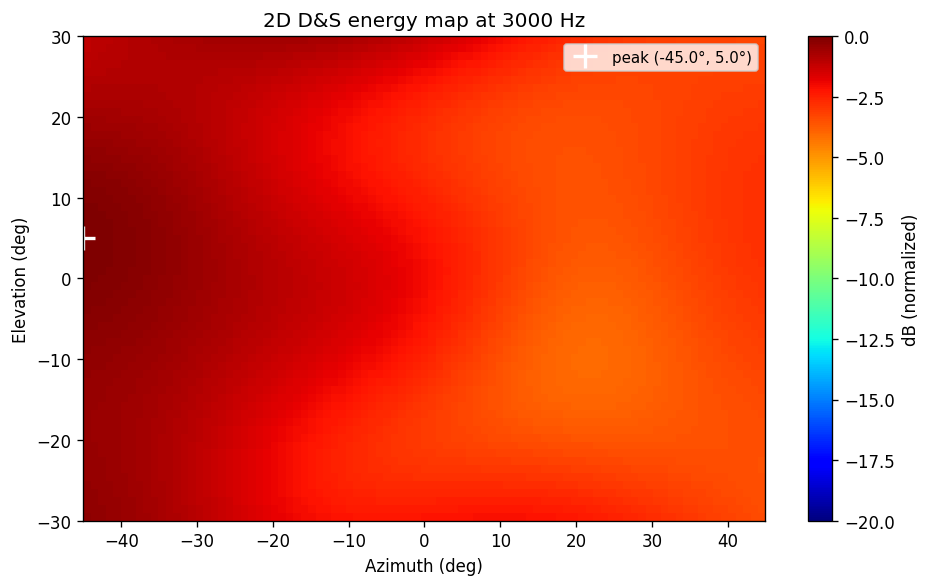

2D peak: az=-45.0°, el=5.0°


In [7]:
N_AZ, N_EL = 91, 61
az_2d = np.linspace(-45, 45, N_AZ)
el_2d = np.linspace(-30, 30, N_EL)

H2d  = steer(az_2d, el_2d, f_act)      # (16, N_AZ * N_EL)
P2d  = bf_ds(R_csm, H2d).reshape(N_AZ, N_EL)
P2d_db = db_norm(P2d)

peak_flat = np.unravel_index(np.argmax(P2d), P2d.shape)
peak_az2d = az_2d[peak_flat[0]]
peak_el2d = el_2d[peak_flat[1]]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(P2d_db.T, origin='lower', aspect='auto',
               extent=[az_2d[0], az_2d[-1], el_2d[0], el_2d[-1]],
               cmap='jet', vmin=-20, vmax=0)
ax.plot(peak_az2d, peak_el2d, 'w+', ms=14, mew=2, label=f'peak ({peak_az2d:.1f}°, {peak_el2d:.1f}°)')
plt.colorbar(im, ax=ax, label='dB (normalized)')
ax.set_xlabel('Azimuth (deg)')
ax.set_ylabel('Elevation (deg)')
ax.set_title(f'2D D&S energy map at {f_act:.0f} Hz')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('uma16_beamform_2d.png', dpi=150)
plt.show()

print(f'2D peak: az={peak_az2d:.1f}°, el={peak_el2d:.1f}°')


## 7  Peak DoA vs Frequency

Sweep from 500 Hz to 5 kHz and record the D&S peak azimuth at each frequency.
Below ~2700 Hz (aperture-limited) and above ~4083 Hz (spatial Nyquist) the
estimate should become unstable.

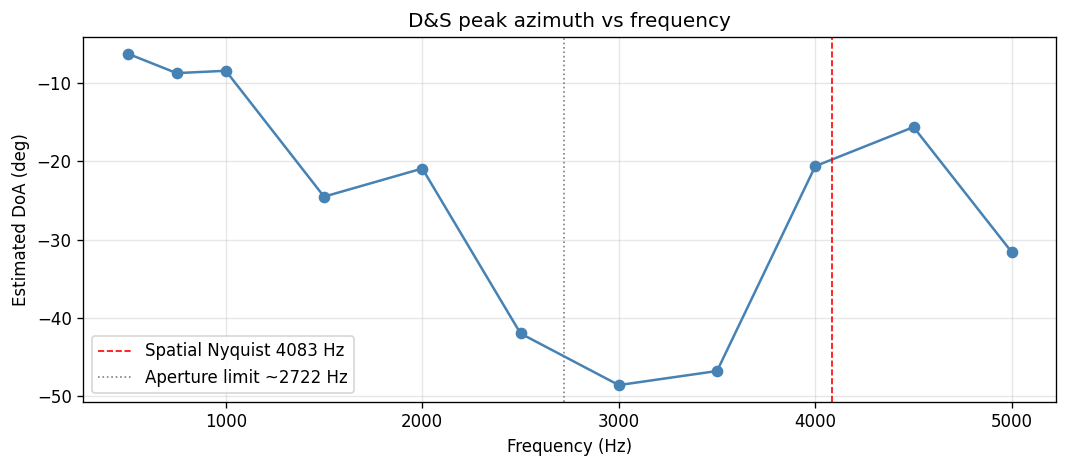

Peak DoA by frequency:
    500 Hz:    -6.2°
    750 Hz:    -8.7°
   1000 Hz:    -8.4°
   1500 Hz:   -24.5°
   2000 Hz:   -20.9°
   2500 Hz:   -42.0°
   3000 Hz:   -48.6°
   3500 Hz:   -46.8°
   4000 Hz:   -20.6°
   4500 Hz:   -15.6°  <- above Nyquist
   5000 Hz:   -31.6°  <- above Nyquist


In [8]:
freqs_sweep = [500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
peak_az_freq = []

for freq in freqs_sweep:
    R_f, f_a, _ = compute_csm(rec, freq)
    H_f = steer(az_grid, el_fix, f_a)
    P_f = bf_ds(R_f, H_f)
    peak_az_freq.append(az_grid[np.argmax(P_f)])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(freqs_sweep, peak_az_freq, 'o-', color='steelblue', lw=1.5)
ax.axvline(NYQUIST, color='red', ls='--', lw=1, label=f'Spatial Nyquist {NYQUIST:.0f} Hz')
ax.axvline(C / 0.126, color='gray', ls=':', lw=1, label=f'Aperture limit ~{C/0.126:.0f} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Estimated DoA (deg)')
ax.set_title('D&S peak azimuth vs frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('uma16_freq_sweep.png', dpi=150)
plt.show()

print('Peak DoA by frequency:')
for freq, az in zip(freqs_sweep, peak_az_freq):
    flag = '  <- above Nyquist' if freq > NYQUIST else ''
    print(f'  {freq:5d} Hz:  {az:+6.1f}°{flag}')


## Summary

Key findings to record in PHASE3.md nb16 Results:
- Device accessible, all 16 channels live, RMS levels balanced
- CSM computed correctly; off-diagonal structure visible (inter-mic correlations)
- 1D peak DoA from D&S, MVDR, CLEAN-SC (record values)
- 2D peak az/el coordinates
- Frequency sweep: stable DoA in 2–4 kHz window, instability above Nyquist


In [9]:
print('=== nb16 Summary ===')
print(f'Device: [{uma_idx}] {uma_dev["name"]}')
print(f'Channels: {uma_dev["max_input_channels"]},  Rate: {FS} Hz')
print(f'RMS spread: {rms_vals.max()/rms_vals.min():.2f}x  '
      f'(max ch{rms_vals.argmax()}, min ch{rms_vals.argmin()})')
print(f'CSM blocks: {n_blocks}  at {f_act:.0f} Hz')
print(f'1D peaks at {f_act:.0f} Hz:')
print(f'  D&S={az_ds:.1f}°  MVDR={az_mvdr:.1f}°  CLEAN-SC={az_clean:.1f}°')
print(f'2D peak: az={peak_az2d:.1f}°  el={peak_el2d:.1f}°')
if abs(az_ds - az_mvdr) < 5 and abs(az_ds - az_clean) < 5:
    print('PASS: algorithms agree within 5°')
else:
    print('NOTE: algorithm estimates differ >5° — ambient or multi-source scene')


=== nb16 Summary ===
Device: [12] UMA16v2: USB Audio (hw:4,0)
Channels: 16,  Rate: 48000 Hz
RMS spread: 1.22x  (max ch14, min ch13)
CSM blocks: 233  at 3000 Hz
1D peaks at 3000 Hz:
  D&S=-48.6°  MVDR=-50.1°  CLEAN-SC=-48.6°
2D peak: az=-45.0°  el=5.0°
PASS: algorithms agree within 5°
